<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/%20MONTES_DE_OCA-ANDRES-DL-TP1-Co25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 24 - 2do bimestre 2026

Este primer TP comienza la semana de la clase 2 y la ventana de entrega estará abierta hasta las **23:59 hs del jueves 21 de mayo (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP1 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/dMmn8VEJmvRmYgvi6)**. Tanto los resultados, tablas, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el mismo notebook.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL ÚNICO MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP1.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP1-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros a optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-10, fin=10`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado). Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para los 3 learning rates. Las 3 gráficas deben estar en el mismo plot para que la comparación visual sea más fácil.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


# Funciones Aux
def tanh(z):
    return np.tanh(z)

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def grad_mse_tanh(x, y_true, w, b):
    z = w * x + b
    y_pred = tanh(z)
    error = y_pred - y_true

    # Derivada de la activación tanh
    dtanh = 1 - y_pred**2

    # Gradientes vectorizados sobre el full batch
    dw = np.mean(2 * error * dtanh * x)
    db = np.mean(2 * error * dtanh)
    return dw, db, y_pred

In [31]:
# Construcción del Dataset Sintético
np.random.seed(1515)
m = 1000
x = np.linspace(-10, 10, m)

# Mapeo sigmoidal y ruido gaussiano
ruido = np.random.normal(loc=0.0, scale=0.05, size=m)
y = 1 / (1 + np.exp(-x)) + ruido

# Setup
epochs = 100
learning_rates = [0.1, 0.01, 0.001]
w_init, b_init = np.random.randn(), np.random.randn()

# Proceso
historial_costos_gd = {}
y_pred_gd = {}

for lr in learning_rates:
    w, b = w_init, b_init
    costos = []

    for epoch in range(epochs):
        dw, db, y_pred = grad_mse_tanh(x, y, w, b)
        costos.append(mse_loss(y, y_pred))
        w -= lr * dw
        b -= lr * db

        if epoch == epochs - 1:
            y_pred_gd[lr] = y_pred

    historial_costos_gd[lr] = costos

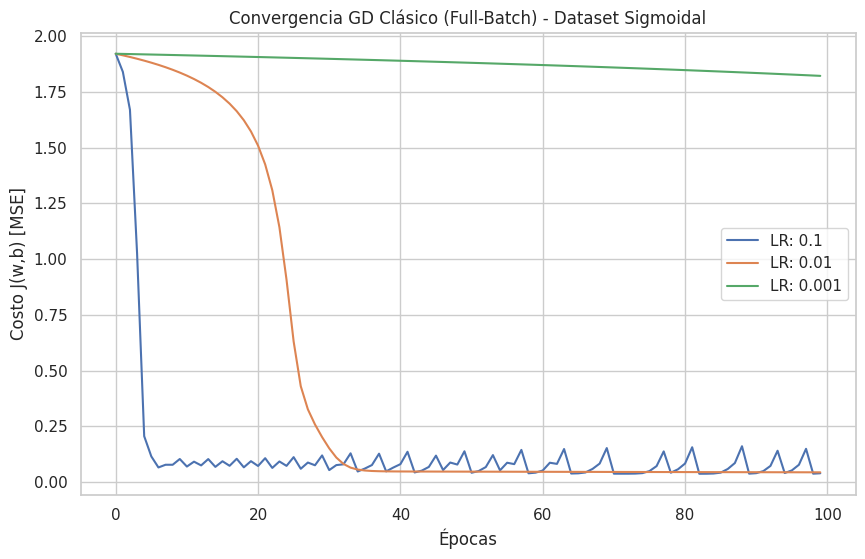

In [32]:
# Plot
plt.figure(figsize=(10, 6))
for lr, costos in historial_costos_gd.items():
    plt.plot(range(epochs), costos, label=f'LR: {lr}')

plt.xlabel('Épocas')
plt.ylabel('Costo J(w,b) [MSE]')
plt.title('Convergencia GD Clásico (Full-Batch) - Dataset Sigmoidal')
plt.legend()
plt.grid(True)
plt.show()

- Se observa como con un LR muy pequeno, tarda demasiado en converger
- En cambio, con un LR muy grande, se converge rapido pero es mucho mas inestable con el paso del tiempo
- Y con un LR medio, se ve como demora mas en converger, pero la misma es mucho mas suave y estable

### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno sin mini-batch (full-batch) y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [33]:
# Adam Full-Batch
batch_size = 128
beta1, beta2, epsilon = 0.9, 0.999, 1e-8

historial_costos_adam_full = {lr: [] for lr in learning_rates}
y_pred_adam_full = {}

for lr in learning_rates:

    w_f, b_f = w_init, b_init # Mismos valores usados antes
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0

    for t in range(1, epochs + 1):
        dw, db, y_pred = grad_mse_tanh(x, y, w_f, b_f)
        historial_costos_adam_full[lr].append(mse_loss(y, y_pred))

        # Propagación de estimadores de 1er y 2do momento con corrección de sesgo (W)
        m_w = beta1 * m_w + (1 - beta1) * dw
        v_w = beta2 * v_w + (1 - beta2) * (dw**2)
        w_f -= lr * (m_w / (1 - beta1**t)) / (np.sqrt(v_w / (1 - beta2**t)) + epsilon)

        # Propagación de estimadores de 1er y 2do momento con corrección de sesgo (B)
        m_b = beta1 * m_b + (1 - beta1) * db
        v_b = beta2 * v_b + (1 - beta2) * (db**2)
        b_f -= lr * (m_b / (1 - beta1**t)) / (np.sqrt(v_b / (1 - beta2**t)) + epsilon)


        if t == epochs:
            y_pred_adam_full[lr] = y_pred


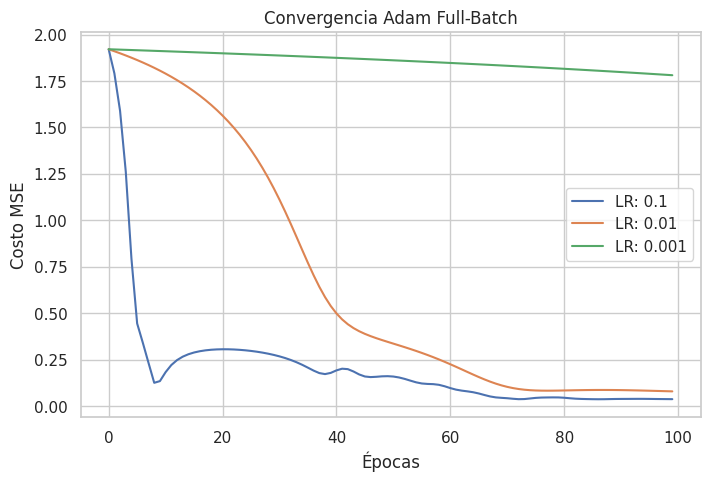

In [34]:
# Plot

plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(range(epochs), historial_costos_adam_full[lr], label=f'LR: {lr}')
plt.xlabel('Épocas')
plt.ylabel('Costo MSE')
plt.title('Convergencia Adam Full-Batch')
plt.legend()
plt.grid(True)

* Adam es mucho más robusto, a diferencia del GD clasico, donde un LR alto (0.1) generaba una oscilacion, Adam logra "autocorregirse" por el efecto de los momentos


In [35]:
# Adam Mini-Batch


historial_costos_adam_mini = {}
y_pred_adam_mini = {}

for lr in learning_rates:
    w_m, b_m = w_init, b_init # Mismos valores usados antes

    # Inicialización nula de estimadores de momento
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0
    t_m = 1
    costos = []

    for epoch in range(epochs):

        indices = np.random.permutation(m)
        x_shuf, y_shuf = x[indices], y[indices]

        for i in range(0, m, batch_size):
            # Extracción asimétrica de tensores de lote
            x_b = x_shuf[i:i + batch_size]
            y_b = y_shuf[i:i + batch_size]

            # Aproximación del gradiente sobre el sub-tensor X_b
            dw, db, _ = grad_mse_tanh(x_b, y_b, w_m, b_m)

            # Estimadores de momento y corrección de sesgo adaptativo (Tensor W)
            m_w = beta1 * m_w + (1 - beta1) * dw
            v_w = beta2 * v_w + (1 - beta2) * (dw**2)
            m_w_hat = m_w / (1 - beta1**t_m)
            v_w_hat = v_w / (1 - beta2**t_m)
            w_m -= lr * m_w_hat / (np.sqrt(v_w_hat) + epsilon)

            # Estimadores de momento y corrección de sesgo adaptativo (Escalar B)
            m_b = beta1 * m_b + (1 - beta1) * db
            v_b = beta2 * v_b + (1 - beta2) * (db**2)
            m_b_hat = m_b / (1 - beta1**t_m)
            v_b_hat = v_b / (1 - beta2**t_m)
            b_m -= lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

            t_m += 1

        # Evaluación del costo global sobre la matriz X completa tras iterar los n/b lotes
        _, _, y_pred_full = grad_mse_tanh(x, y, w_m, b_m)
        costos.append(mse_loss(y, y_pred_full))

        if epoch == epochs - 1:
            y_pred_adam_mini[lr] = y_pred_full

    historial_costos_adam_mini[lr] = costos

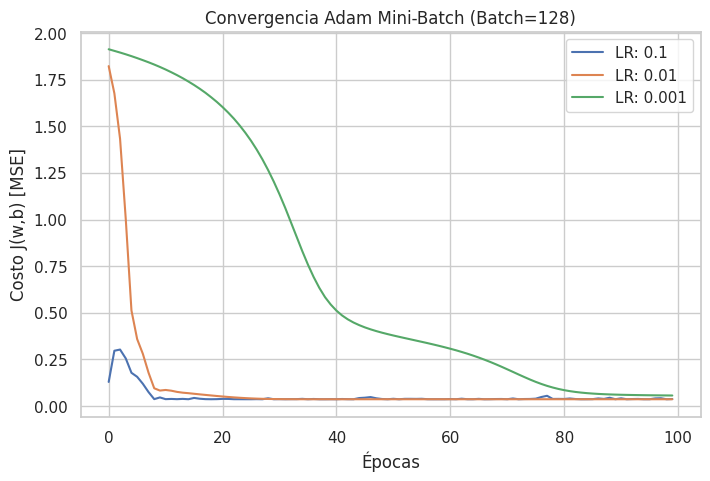

In [36]:
# Plot
plt.figure(figsize=(8, 5))
for lr, costos in historial_costos_adam_mini.items():
    plt.plot(range(epochs), costos, label=f'LR: {lr}')

plt.xlabel('Épocas')
plt.ylabel('Costo J(w,b) [MSE]')
plt.title(f'Convergencia Adam Mini-Batch (Batch={batch_size})')
plt.legend()
plt.grid(True)
plt.show()

* Al actualizar los pesos por cada lote (y no al final de toda la epoca), el tiempo de convergencia se reduce para todos los LRs
* Esto permite converger utilizando LRs pequenos, a diferencia de los metodos anteriores

### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes.

Métricas de convergencia terminal (Época 100):


<>:32: SyntaxWarning: invalid escape sequence '\h'
<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:32: SyntaxWarning: invalid escape sequence '\h'
<>:51: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_8599/3684211359.py:32: SyntaxWarning: invalid escape sequence '\h'
  fig.suptitle('Mapeo No Lineal: Inferencia $\hat{y}$ vs Función Subyacente $y(x)$', fontsize=14, fontweight='bold')
/tmp/ipykernel_8599/3684211359.py:51: SyntaxWarning: invalid escape sequence '\h'
  ax.plot(x[idx_sort], predicciones[lr][idx_sort], color='red', linewidth=2, label='Inferencia $\hat{y}$')


,Learning Rate (η),GD (MSE),Adam Full-Batch (MSE),Adam Mini-Batch (MSE)
0,0.100,0.039277,0.036868,0.037456
1,0.010,0.043528,0.078840,0.036288
2,0.001,1.822200,1.781575,0.056346


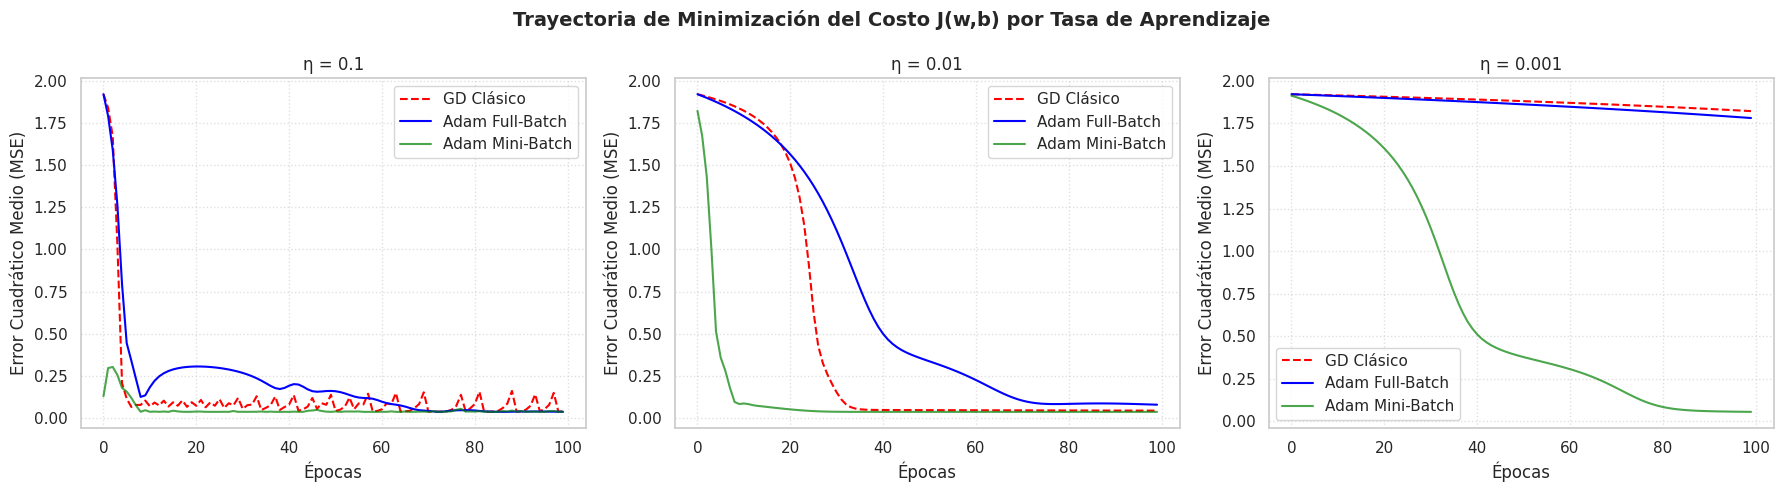

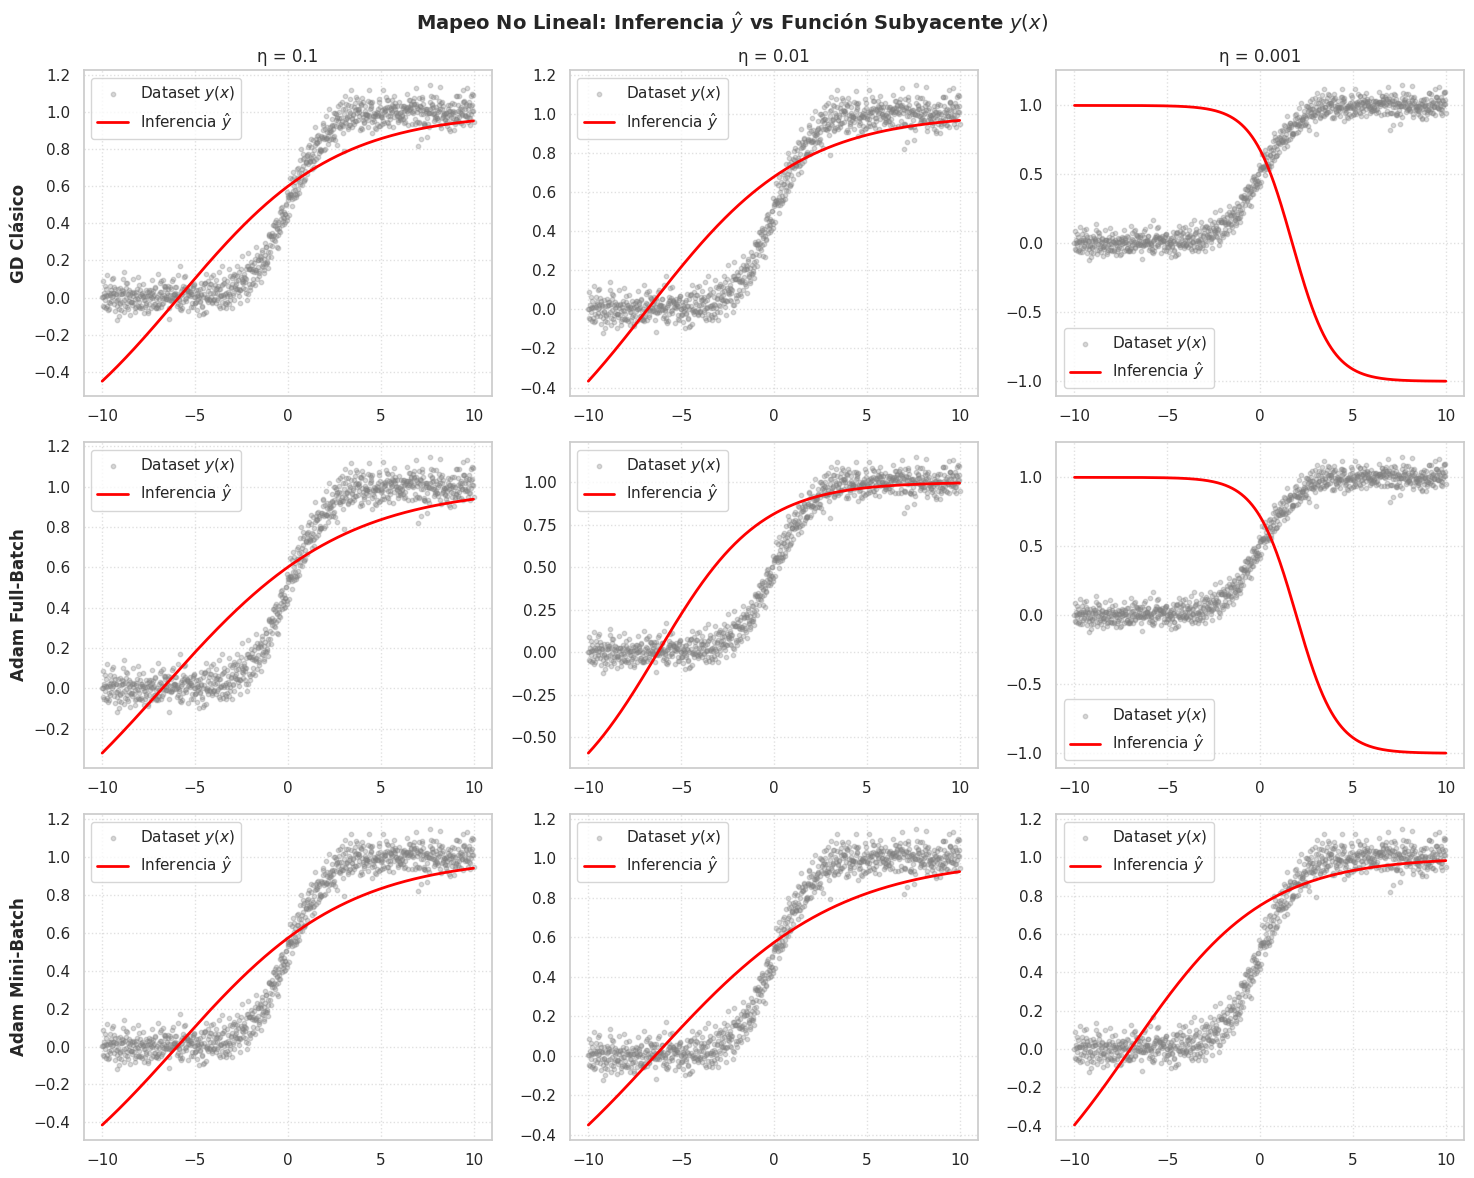

In [37]:
# 1. Matriz Analítica de Rendimiento Asintótico
df_mse = pd.DataFrame({
    'Learning Rate (η)': learning_rates,
    'GD (MSE)': [historial_costos_gd[lr][-1] for lr in learning_rates], # Puntero adaptado a tu nomenclatura base
    'Adam Full-Batch (MSE)': [historial_costos_adam_full[lr][-1] for lr in learning_rates],
    'Adam Mini-Batch (MSE)': [historial_costos_adam_mini[lr][-1] for lr in learning_rates]
})

print("Métricas de convergencia terminal (Época 100):")
display(df_mse)

# 2. Análisis Topológico de la Convergencia de J(w,b) (3 Subplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Trayectoria de Minimización del Costo J(w,b) por Tasa de Aprendizaje', fontsize=14, fontweight='bold')

for i, lr in enumerate(learning_rates):
    axes[i].plot(range(epochs), historial_costos_gd[lr], label='GD Clásico', linestyle='--', color='red')
    axes[i].plot(range(epochs), historial_costos_adam_full[lr], label='Adam Full-Batch', color='blue')
    axes[i].plot(range(epochs), historial_costos_adam_mini[lr], label='Adam Mini-Batch', color='green', alpha=0.7)

    axes[i].set_title(f'η = {lr}')
    axes[i].set_xlabel('Épocas')
    axes[i].set_ylabel('Error Cuadrático Medio (MSE)')
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Proyección del Hiperplano Inferido vs Dataset Original (Grilla 3x3)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Mapeo No Lineal: Inferencia $\hat{y}$ vs Función Subyacente $y(x)$', fontsize=14, fontweight='bold')

optimizadores = [
    ('GD Clásico', y_pred_gd), # Reemplazar por y_pred si no utilizaste el sufijo _gd
    ('Adam Full-Batch', y_pred_adam_full),
    ('Adam Mini-Batch', y_pred_adam_mini)
]

# Ordenamiento del tensor unidimensional para asegurar una interpolación continua
idx_sort = np.argsort(x)

for row, (nombre_opt, predicciones) in enumerate(optimizadores):
    for col, lr in enumerate(learning_rates):
        ax = axes[row, col]

        # Dispersión estocástica del dataset
        ax.scatter(x, y, color='gray', alpha=0.3, label='Dataset $y(x)$', s=10)

        # Interpolación de la predicción
        ax.plot(x[idx_sort], predicciones[lr][idx_sort], color='red', linewidth=2, label='Inferencia $\hat{y}$')

        if row == 0:
            ax.set_title(f'η = {lr}')
        if col == 0:
            ax.set_ylabel(nombre_opt, fontweight='bold', fontsize=12)

        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend()

plt.tight_layout()
plt.show()

- Para los LRs de 0.1 y 0.01, los tres algoritmos predicen bastante bien, con un MSE que ronda entre 0.035 y 0.07

- Tambien se observa en los plots, como como para esos LRs, la inferencia sigue un patron similar al de la distribucion original (sigmoide + random)

- Velocidad de convergencia: Adam Mini-Batch llega al mínimo casi instantáneamente en casi todos los casos

- Para el LR más chico, GD y Adam Full-Batch fallan en converger. El paso es tan pequeño que el algoritmo queda "estancado" por falta de velocidad. En el plot de mapeo se ve que la línea roja ni siquiera se ajusta a los datos, no le dieron los epoch para aprender

- Adam Mini-Batch es el mas robusto, es el unico que logra converger con la LR mas baja de 0.001. Esto se debe a que las actualizaciones frecuentes por lote compensan el tamaño pequeño del paso.


### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)

- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico. También si desean pueden hacer que el gráfico sea animado usando `matplotlib.animation` y `IPython.display`.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia.

In [38]:
# Re-define the synthetic dataset for this section (originally from cell gxwZwvZYLPdy)
np.random.seed(1515)
m = 1000
x_synthetic = np.linspace(-10, 10, m)
ruido = np.random.normal(loc=0.0, scale=0.05, size=m)
y_synthetic = 1 / (1 + np.exp(-x_synthetic)) + ruido

# Setup for optimizers (epochs, learning_rates, initial weights, etc.)
epochs = 100
learning_rates = [0.1, 0.01, 0.001]
w_init, b_init = np.random.randn(), np.random.randn()



# GD Clásico
historial_w_gd = {} # Almacena w en cada época
historial_b_gd = {} # Almacena b en cada época

for lr in learning_rates:
    w, b = w_init, b_init
    ws, bs = [], []
    for epoch in range(epochs):
        ws.append(w)
        bs.append(b)
        # Use synthetic data for this section
        dw, db, _ = grad_mse_tanh(x_synthetic, y_synthetic, w, b)
        w -= lr * dw
        b -= lr * db
    historial_w_gd[lr] = ws
    historial_b_gd[lr] = bs

# Adam Full-Batch
historial_w_adam_full = {} # Almacena w en cada época
historial_b_adam_full = {} # Almacena b en cada época

for lr in learning_rates:
    w_f, b_f = w_init, b_init
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0
    ws_f, bs_f = [], []
    for t in range(1, epochs + 1):
        ws_f.append(w_f)
        bs_f.append(b_f)
        # Use synthetic data for this section
        dw, db, _ = grad_mse_tanh(x_synthetic, y_synthetic, w_f, b_f)

        m_w = beta1 * m_w + (1 - beta1) * dw
        v_w = beta2 * v_w + (1 - beta2) * (dw**2)
        w_f -= lr * (m_w / (1 - beta1**t)) / (np.sqrt(v_w / (1 - beta2**t)) + epsilon)

        m_b = beta1 * m_b + (1 - beta1) * db
        v_b = beta2 * v_b + (1 - beta2) * (db**2)
        b_f -= lr * (m_b / (1 - beta1**t)) / (np.sqrt(v_b / (1 - beta2**t)) + epsilon)
    historial_w_adam_full[lr] = ws_f
    historial_b_adam_full[lr] = bs_f

# Adam Mini-Batch
historial_w_adam_mini = {} # Almacena w en cada época
historial_b_adam_mini = {} # Almacena b en cada época

# Define beta1, beta2, epsilon, and batch_size if not already defined
# (These were defined in bd2wWPyXUPSu, but good to ensure local scope if needed)
beta1, beta2, epsilon = 0.9, 0.999, 1e-8
batch_size = 128 # Or whatever batch_size was intended for this part

for lr in learning_rates:
    w_m, b_m = w_init, b_init
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0
    t_m = 1
    ws_m, bs_m = [], []

    for epoch in range(epochs):
        # Almacenar w y b al inicio de cada época (después de las actualizaciones del epoch anterior)
        ws_m.append(w_m)
        bs_m.append(b_m)

        # Use m from synthetic dataset
        indices = np.random.permutation(m)
        x_shuf, y_shuf = x_synthetic[indices], y_synthetic[indices]

        for i in range(0, m, batch_size):
            x_b = x_shuf[i:i + batch_size]
            y_b = y_shuf[i:i + batch_size]
            # Use synthetic data for this section
            dw, db, _ = grad_mse_tanh(x_b, y_b, w_m, b_m)

            m_w = beta1 * m_w + (1 - beta1) * dw
            v_w = beta2 * v_w + (1 - beta2) * (dw**2)
            m_w_hat = m_w / (1 - beta1**t_m)
            v_w_hat = v_w / (1 - beta2**t_m)
            w_m -= lr * m_w_hat / (np.sqrt(v_w_hat) + epsilon)

            m_b = beta1 * m_b + (1 - beta1) * db
            v_b = beta2 * v_b + (1 - beta2) * (db**2)
            m_b_hat = m_b / (1 - beta1**t_m)
            v_b_hat = v_b / (1 - beta2**t_m)
            b_m -= lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

            t_m += 1

    historial_w_adam_mini[lr] = ws_m
    historial_b_adam_mini[lr] = bs_m

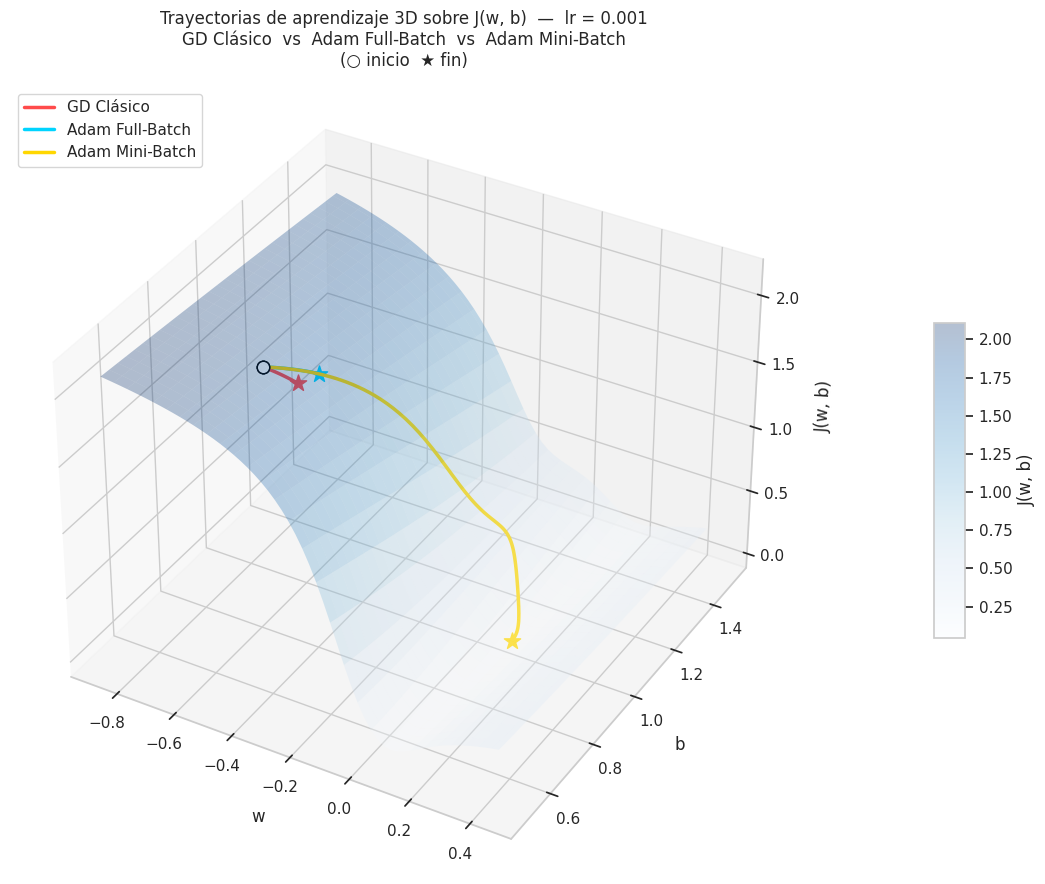

In [39]:
from mpl_toolkits.mplot3d import Axes3D

lr = 0.001 # La que vimos en el punto anterior, donde se nota la diferencia entre los otros

ws_gd  = historial_w_gd[lr]
bs_gd  = historial_b_gd[lr]
ws_af  = historial_w_adam_full[lr]
bs_af  = historial_b_adam_full[lr]
ws_am  = historial_w_adam_mini[lr]
bs_am  = historial_b_adam_mini[lr]

# ── Acotar la superficie al rango real de las trayectorias ───────────────────
all_ws = ws_gd + ws_af + ws_am
all_bs = bs_gd + bs_af + bs_am
margin = 0.3
w_lo, w_hi = min(all_ws) - margin, max(all_ws) + margin
b_lo, b_hi = min(all_bs) - margin, max(all_bs) + margin

w_range = np.linspace(w_lo, w_hi, 60)
b_range = np.linspace(b_lo, b_hi, 60)
W_grid, B_grid = np.meshgrid(w_range, b_range)

Z_grid = np.zeros_like(W_grid)
for i in range(W_grid.shape[0]):
    for j in range(W_grid.shape[1]):
        # grad_mse_tanh returns dw, db, y_pred. We need to calculate the scalar MSE cost from y_pred.
        _, _, y_pred_current = grad_mse_tanh(x_synthetic, y_synthetic, W_grid[i, j], B_grid[i, j])
        Z_grid[i, j] = mse_loss(y_synthetic, y_pred_current)

# ── Calcular J en cada trayectoria ────────────────────────────────────────────
def traj_cost(ws, bs):
    costs = []
    for w, b in zip(ws, bs):
        _, _, y_pred_val = grad_mse_tanh(x_synthetic, y_synthetic, w, b)
        costs.append(mse_loss(y_synthetic, y_pred_val))
    return costs

jgd = traj_cost(ws_gd, bs_gd)
jaf = traj_cost(ws_af, bs_af)
jam = traj_cost(ws_am, bs_am)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

# Superficie única con colormap neutro y alpha bajo
surf = ax.plot_surface(W_grid, B_grid, Z_grid,
                       cmap='Blues', alpha=0.30,
                       linewidth=0, antialiased=True)

# Trayectorias
colors = ['#FF4B4B', '#00D4FF', '#FFD700']
names  = ['GD Clásico', 'Adam Full-Batch', 'Adam Mini-Batch']
trajs  = [(ws_gd, bs_gd, jgd), (ws_af, bs_af, jaf), (ws_am, bs_am, jam)]

for (ws, bs, js), color, name in zip(trajs, colors, names):
    ax.plot(ws, bs, js, color=color, linewidth=2.5, label=name, zorder=5)
    # Inicio
    ax.scatter([ws[0]], [bs[0]], [js[0]],
               color='white', edgecolors='black', s=80, zorder=10, depthshade=False)
    # Fin
    ax.scatter([ws[-1]], [bs[-1]], [js[-1]],
               color=color, marker='*', s=150, zorder=10, depthshade=False)

# Colorbar de la superficie (referencia de J)
fig.colorbar(surf, ax=ax, shrink=0.4, aspect=10, pad=0.1, label='J(w, b)')

ax.set_xlabel('w', labelpad=10, fontsize=12)
ax.set_ylabel('b', labelpad=10, fontsize=12)
ax.set_zlabel('J(w, b)', labelpad=10, fontsize=12)
ax.set_title(
    f'Trayectorias de aprendizaje 3D sobre J(w, b)  —  lr = {lr}\n'
    'GD Clásico  vs  Adam Full-Batch  vs  Adam Mini-Batch\n'
    '(○ inicio  ★ fin)',
    fontsize=12, pad=15
)
ax.legend(loc='upper left', fontsize=11)

# Ángulo de cámara: elevar más para ver la "bajada" de cada trayectoria
ax.view_init(elev=35, azim=-60)

plt.tight_layout()
plt.savefig('trayectorias_3d.png', dpi=150, bbox_inches='tight')
plt.show()

* Con lr = 0.001 y 100 épocas, GD Clásico y Adam Full-Batch no logran converger, quedando atrapados cerca del punto de inicio
* Adam Mini-Batch es el único que desciende efectivamente la superficie de costo, gracias a que actualiza los parámetros múltiples veces por época (una vez por cada mini-batch), acumulando muchos más pasos de optimización en el mismo número de épocas


### **RECOMENDACIÓN**:

Voy a valorar mucho que sus análisis, explicaciones y conclusiones sean bastante detalladas y con coherencia en los resultados obtenidos. Donde se evidencie un análisis propio de un humano estudiante de posgrado y no solo copiar y pegar lo que te dijo ChatGPT. Llevo ya años con esto, así que me daré cuenta rapidamente cuando sea así y cuando no.

Les recomiendo revisar el notebook sobre optimizadores que se encuentra en el repo. Pueden acceder mediante el siguiente [enlace](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/blob/ap_2026/CLASE%202/Notebooks/clase2_4_optimizadores.ipynb). En ese notebook vemos cómo aplicar GD y Adam full-batch para una red con relación lineal. Les servirá mucho como guía para realizar esta pregunta. Ahí también podrán ver cómo se hace una animación de un gráfico 3D.

Además, de igual forma tienen disponible el siguiente [material adicional del repo](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/tree/ap_2026/CLASE%202/Teoria/Material%20adicional), el cual le servirá para aplicar Adam, ya no solo en su versión full-batch, sino también en mini-batch

# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

**Descarga del dataset:**  
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- **User_ID:** Código identificador único del cliente que efectuó la compra.  
- **Product_ID:** Código identificador único del producto adquirido.  
- **Age:** Rango de edad del cliente.  
- **Gender:** Género del cliente (F: Femenino, M: Masculino).  
- **Marital_Status:** Estado civil del cliente (0: Soltero, 1: Casado).  
- **City_Category:** Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- **Stay_In_Current_City_Years:** Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- **Product_Category:** Categoría del producto comprado.  
- **Product_Subcategory_1:** Subcategoría principal del producto.  
- **Product_Subcategory_2:** Subcategoría secundaria del producto.  
- **Purchase:** Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra. Tener en cuenta que se busca que el modelo prediga el gasto promedio por cliente, no el gasto en cada nueva transacción individual.


### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage**.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.


#### Cargo los datos

In [40]:
# Librerias

import pandas as pd
import gdown
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Added OneHotEncoder
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score
import torch
import torch.nn as nn
import torch.optim as optim


# Google Drive file ID for the dataset
file_id = '1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ'

# Output filename
output_filename = 'customer_data.csv'

# Download the file from Google Drive using gdown
gdown.download(id=file_id, output=output_filename, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ
To: /content/customer_data.csv
100%|██████████| 8.41M/8.41M [00:00<00:00, 56.8MB/s]


'customer_data.csv'

In [41]:
# Load the CSV file into a pandas DataFrame
data = pd.read_csv(output_filename)

# Display the first 5 rows of the DataFrame
print(f"Successfully loaded '{output_filename}' into a DataFrame. First 5 rows:")
display(data.head())

Successfully loaded 'customer_data.csv' into a DataFrame. First 5 rows:


,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142


In [42]:
print(f"Shape of the DataFrame: {data.shape}")
print("Data types of the columns:")
display(data.info())

Shape of the DataFrame: (182721, 11)
Data types of the columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     182721 non-null  int64  
 1   Product_ID                  182721 non-null  object 
 2   Age                         182721 non-null  object 
 3   Gender                      182721 non-null  object 
 4   Marital_Status              182721 non-null  int64  
 5   City_Category               182721 non-null  object 
 6   Stay_In_Current_City_Years  182721 non-null  object 
 7   Product_Category            182721 non-null  int64  
 8   Product_Subcategory_1       140903 non-null  float64
 9   Product_Subcategory_2       77461 non-null   float64
 10  Purchase                    182721 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 15.3+ MB


None

* 180,000 registros transaccionales

#### Analizo el Target

In [43]:
# Distribucion del Target

data["Purchase"].describe()

,Purchase
count,182721.000000
mean,7851.668971
std,8321.461408
min,45.000000
25%,578.000000
50%,5060.000000
75%,11930.000000
max,29980.000000


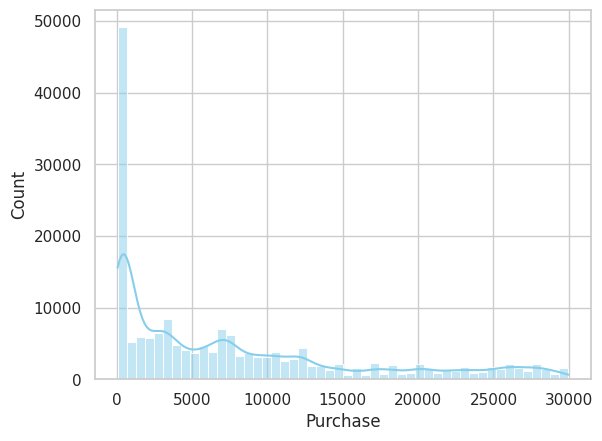

In [44]:
sns.histplot(data["Purchase"], kde=True, bins=50, color="skyblue")
plt.show()

* La gran mayoria son transacciones pequeñas

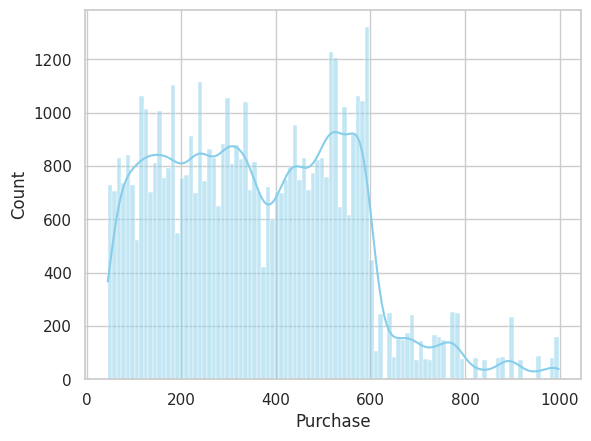

In [45]:
sns.histplot(data[data["Purchase"] < 1000]["Purchase"], bins=100, kde=True, color="skyblue")
plt.show()

* Se ve un corte grande en compras menores a $600, sera algun tema fiscal?
* Importante para el FE

#### Analisis de Nulls

In [46]:
print("Percentage of missing values per column:")
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Percentage': missing_percentage})
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Percentage', ascending=False))

Percentage of missing values per column:


,Missing Count,Percentage
Product_Subcategory_2,105260,57.606953
Product_Subcategory_1,41818,22.886258


- En principio no vamos a hacer mucho con estas variables, asi que no vamos a tratar a los nulos

#### Analisis de Variables Categoricas

In [47]:
# Transformamos las enteras que son categoricas por el EDA
data = data.astype({
    'Marital_Status': 'object',
    'Product_Category': 'object',
    'Product_Subcategory_1': 'object',
    'Product_Subcategory_2': 'object'

})

Unique values and counts for categorical columns:

Column: Age


<Axes: xlabel='Age'>

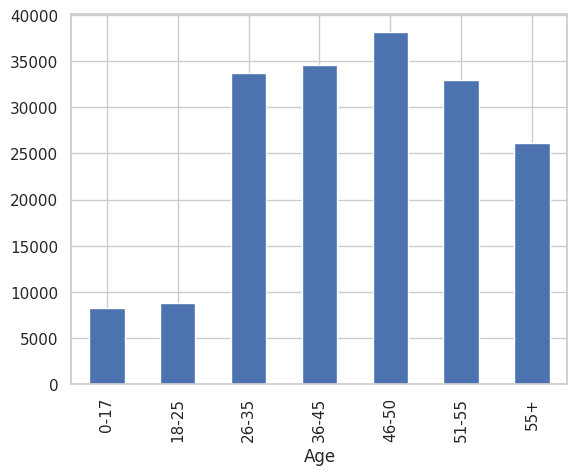

Number of unique values: 7

Column: Gender


<Axes: xlabel='Gender'>

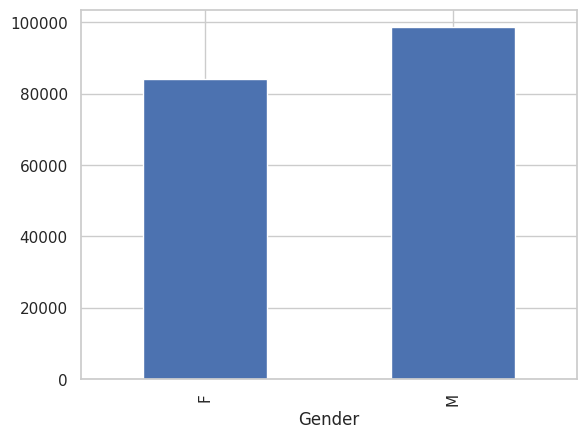

Number of unique values: 2

Column: Marital_Status


<Axes: xlabel='Marital_Status'>

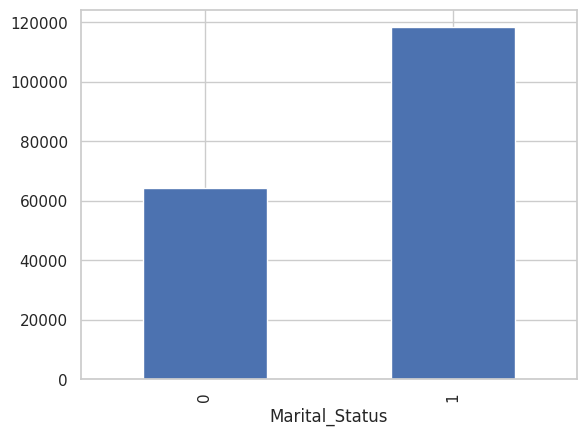

Number of unique values: 2

Column: City_Category


<Axes: xlabel='City_Category'>

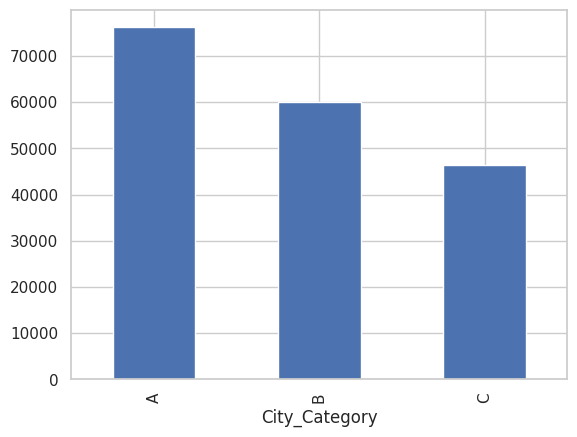

Number of unique values: 3

Column: Stay_In_Current_City_Years


<Axes: xlabel='Stay_In_Current_City_Years'>

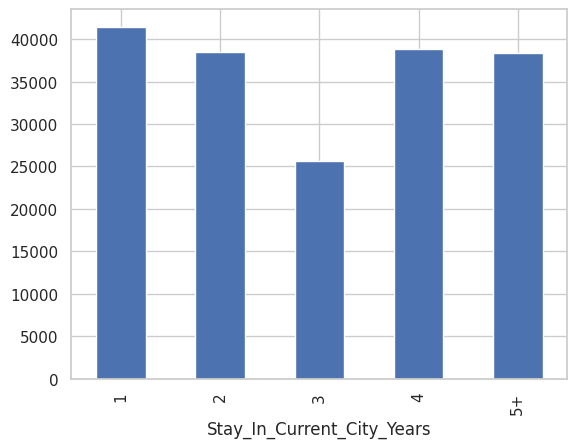

Number of unique values: 5

Column: Product_Category


<Axes: xlabel='Product_Category'>

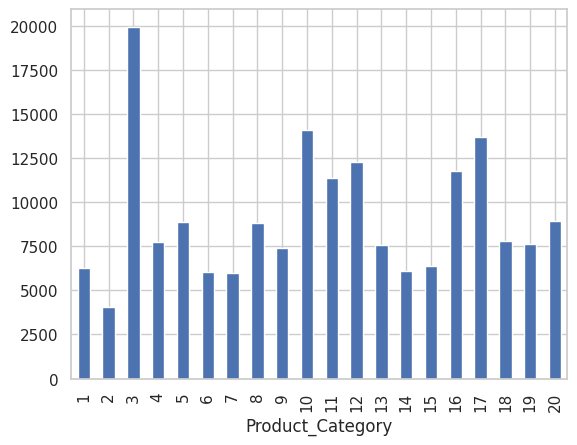

Number of unique values: 20

Column: Product_Subcategory_1


<Axes: xlabel='Product_Subcategory_1'>

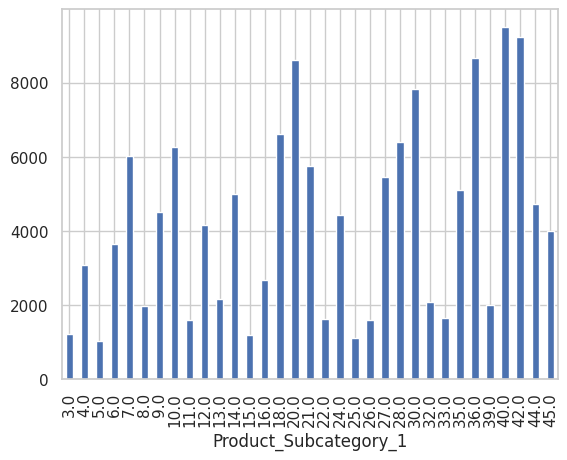

Number of unique values: 33

Column: Product_Subcategory_2


<Axes: xlabel='Product_Subcategory_2'>

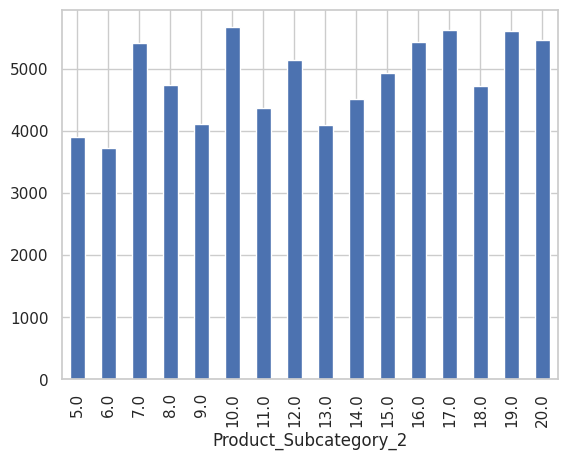

Number of unique values: 16


In [48]:
# Identify categorical columns (object dtype)
categorical_cols = data.select_dtypes(include=['object']).columns
categorical_cols = categorical_cols.drop('Product_ID') # No suma

print("Unique values and counts for categorical columns:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    display(data[col].value_counts().sort_index().plot(kind='bar')) # Mejor ploteamos
    plt.show()
    print(f"Number of unique values: {data[col].nunique()}")

* Categoricas Ordinales:  Age, City_Category y Stay_In_Current_City_Years
* Booleanas: Gender y Marital_Status
* Categorias y Subcategorias tienen alta cardinalidad. Requiere mas analisis

##### Categoricas Ordinales

In [49]:
# Transformamos las Ordinales

from sklearn.preprocessing import OrdinalEncoder

# Define the categories for each feature in their correct ordinal order
age_categories = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
city_categories = ['A', 'B', 'C'] # Assuming A < B < C
stay_years_categories = ['0', '1', '2', '3', '4', '5+']

# Create an OrdinalEncoder instance with the defined categories
# Handle unknown categories by encoding them as the last category, or raise an error if preferred
encoder = OrdinalEncoder(
    categories=[age_categories, city_categories, stay_years_categories],
    handle_unknown='use_encoded_value',
    unknown_value=-1 # Assign -1 to unknown categories, or choose another appropriate value
)

# Apply ordinal encoding to the specified columns
data[['Age', 'City_Category', 'Stay_In_Current_City_Years']] = encoder.fit_transform(
    data[['Age', 'City_Category', 'Stay_In_Current_City_Years']]
)

# Renombramos
data.rename(columns={
    'Age': 'ORD_Age',
    'City_Category': 'ORD_City_Category',
    'Stay_In_Current_City_Years': 'ORD_Stay_In_Current_City_Years'
}, inplace=True)

display(data[['ORD_Age', 'ORD_City_Category', 'ORD_Stay_In_Current_City_Years']].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 3 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ORD_Age                         182721 non-null  float64
 1   ORD_City_Category               182721 non-null  float64
 2   ORD_Stay_In_Current_City_Years  182721 non-null  float64
dtypes: float64(3)
memory usage: 4.2 MB


None

* Se transforman las variables Categoricas Ordinales

##### Booleanas

In [50]:
# Transformamos las Booleanas

data['BOOL_Gender'] = data['Gender'].map({'F': 0, 'M': 1})
data['BOOL_Marital_Status'] = data['Marital_Status'].map({0: 0, 1: 1})

data.drop(columns=["Gender", "Marital_Status"], inplace=True)

* Se transforman y se renombran por Is_Male e Is_Married respectivamente

#### Agregamos la base por usuario

##### Confirmamos que la data por usuario es consistente

In [51]:
user_features = ['ORD_Age', 'BOOL_Gender', 'BOOL_Marital_Status', 'ORD_City_Category', 'ORD_Stay_In_Current_City_Years']

for feature in user_features:
    # Group by User_ID and count unique values for the current feature
    unique_counts = data.groupby('User_ID')[feature].nunique()

    # Check if all users have only one unique value for this feature
    if unique_counts.max() == 1:
        print(f"Feature '{feature}' is consistent for all users (only one unique value per User_ID).")
    else:
        print(f"Feature '{feature}' is NOT consistent for all users (some users have multiple unique values).")
        # Optionally, display users with inconsistencies
        inconsistent_users = unique_counts[unique_counts > 1]
        print(f"  Inconsistent users for '{feature}': {inconsistent_users.index.tolist()}")

Feature 'ORD_Age' is consistent for all users (only one unique value per User_ID).
Feature 'BOOL_Gender' is consistent for all users (only one unique value per User_ID).
Feature 'BOOL_Marital_Status' is consistent for all users (only one unique value per User_ID).
Feature 'ORD_City_Category' is consistent for all users (only one unique value per User_ID).
Feature 'ORD_Stay_In_Current_City_Years' is consistent for all users (only one unique value per User_ID).


* Atributos del usuario consistentes
* Age y Stay_In_Current_City_Years no cambian, la muestra debe ser menor de un año

##### Creamos el schema de la tabla final

In [52]:
data_final = data[['User_ID', 'ORD_Age', 'BOOL_Gender', 'BOOL_Marital_Status', 'ORD_City_Category', 'ORD_Stay_In_Current_City_Years']].drop_duplicates(subset=['User_ID']).reset_index(drop=True)

print("Master table 'df' created with unique User_ID and their personal features:")
display(data_final.head())
print(f"Shape of master table: {data_final.shape}")

Master table 'df' created with unique User_ID and their personal features:


,User_ID,ORD_Age,BOOL_Gender,BOOL_Marital_Status,ORD_City_Category,ORD_Stay_In_Current_City_Years
0,1044096,4.0,0,1,1.0,1.0
1,1071818,3.0,1,0,0.0,3.0
2,1022986,3.0,1,1,0.0,5.0
3,1094684,3.0,1,1,0.0,1.0
4,1004157,4.0,1,1,0.0,5.0


Shape of master table: (7432, 6)


#### Feature Engineering (WIP)

##### Manejo de Categorias

In [53]:
data[["Product_Category", "Product_Subcategory_1", "Product_Subcategory_2"]].nunique()

,0
Product_Category,20
Product_Subcategory_1,33
Product_Subcategory_2,16


* Alta cardinalidad en las Categorias y Subcategorias

###### Generacion de product_number (concatenacion de categoria de productos yu subproductos)
Nota: Al final no la vamos a usar

In [54]:
# Columnas a procesar
cols = ["Product_Category", "Product_Subcategory_1", "Product_Subcategory_2"]

# 1. Limpieza, formateo y relleno de nulos con "00"
for col in cols:
    data[col] = data[col].fillna(0).astype(int).astype(str).str.zfill(2)

# 2. Creación de product_number (6 caracteres)
data['product_number'] = data['Product_Category'] + data['Product_Subcategory_1'] + data['Product_Subcategory_2']

# Verificación rápida
print(data[['Product_Category', 'Product_Subcategory_1', 'Product_Subcategory_2', 'product_number']].head())

/tmp/ipykernel_8599/2456289101.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].fillna(0).astype(int).astype(str).str.zfill(2)
/tmp/ipykernel_8599/2456289101.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].fillna(0).astype(int).astype(str).str.zfill(2)
/tmp/ipykernel_8599/2456289101.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_o

  Product_Category Product_Subcategory_1 Product_Subcategory_2 product_number
0               10                    45                    00         104500
1               11                    27                    00         112700
2               04                    28                    00         042800
3               16                    09                    08         160908
4               03                    00                    00         030000


In [55]:
# Calculamos la moda del Product Number
mode_product = data.groupby('User_ID')['product_number'].apply(lambda x: x.mode().iloc[0]).reset_index(name='CAT_product_number_mode')

print("Moda de product_number por cada User_ID:")
display(mode_product.head())
display(mode_product.info())

Moda de product_number por cada User_ID:


,User_ID,CAT_product_number_mode
0,1000035,162000
1,1000044,012716
2,1000070,140900
3,1000087,200000
4,1000115,030000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7432 entries, 0 to 7431
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   User_ID                  7432 non-null   int64 
 1   CAT_product_number_mode  7432 non-null   object
dtypes: int64(1), object(1)
memory usage: 116.3+ KB


None

In [56]:
mode_product.value_counts().sort_values()

,,count
User_ID,CAT_product_number_mode,
1000264,022100,1
1000270,190020,1
1000274,060000,1
1000278,041200,1
1000304,032200,1
...,...,...
1000186,014200,1
1000201,031517,1
1000213,012100,1


* No se observa ningun producto ctaegoria + subcat1 + subcat2 que se venda mas que otros, todos con value_counts de uno

##### Generación de features de `Purchase` por `Product_Category` (Min y Max)
Para mi, esto es Data Leakage

In [57]:
# Calcular el gasto mínimo por User_ID y Product_Category
min_purchase_category = data.groupby(['User_ID', 'Product_Category'])['Purchase'].min().reset_index()
min_purchase_category_pivot = min_purchase_category.pivot(index='User_ID', columns='Product_Category', values='Purchase').fillna(0)
min_purchase_category_pivot.columns = [f'MIN_Purchase_Cat_{col}' for col in min_purchase_category_pivot.columns]

# Calcular el gasto máximo por User_ID y Product_Category
max_purchase_category = data.groupby(['User_ID', 'Product_Category'])['Purchase'].max().reset_index()
max_purchase_category_pivot = max_purchase_category.pivot(index='User_ID', columns='Product_Category', values='Purchase').fillna(0)
max_purchase_category_pivot.columns = [f'MAX_Purchase_Cat_{col}' for col in max_purchase_category_pivot.columns]

# # Sube el R2 en test de .625 a .94 con estos Atributos, para mo es Data Leakage
# # Unir las nuevas características al DataFrame principal
# data_final = pd.merge(data_final, min_purchase_category_pivot, on='User_ID', how='left')
# data_final = pd.merge(data_final, max_purchase_category_pivot, on='User_ID', how='left')

print("DataFrame 'df' actualizado con features de compra por categoría:")
display(data_final.head())
print(f"Nueva forma del DataFrame 'df': {data_final.shape}")

DataFrame 'df' actualizado con features de compra por categoría:


,User_ID,ORD_Age,BOOL_Gender,BOOL_Marital_Status,ORD_City_Category,ORD_Stay_In_Current_City_Years
0,1044096,4.0,0,1,1.0,1.0
1,1071818,3.0,1,0,0.0,3.0
2,1022986,3.0,1,1,0.0,5.0
3,1094684,3.0,1,1,0.0,1.0
4,1004157,4.0,1,1,0.0,5.0


Nueva forma del DataFrame 'df': (7432, 6)


##### Categoria Preferida

In [58]:
# 1. Armas el DataFrame base
categoria_preferida = (
    data.groupby(["User_ID", "Product_Category"])["Purchase"]
    .sum()
    .reset_index()
    .sort_values("Purchase", ascending=False)
    .drop_duplicates(subset=["User_ID"])
    .sort_values("User_ID")
    .rename(columns={"Product_Category": "CAT_preferida"})
    .drop(columns="Purchase")
)

# 2. Agrupas las minoritarias en 'OTRAS' en una sola línea
counts = categoria_preferida["CAT_preferida"].value_counts()
categoria_preferida["CAT_preferida"] = categoria_preferida["CAT_preferida"].mask(
    categoria_preferida["CAT_preferida"].isin(counts[counts < 200].index), 00
)

# 3. Validás el resultado
categoria_preferida["CAT_preferida"].value_counts()

,count
CAT_preferida,
03,1646
20,1319
19,911
18,861
13,843
12,532
11,446
09,342
07,217


##### Derivadas de Purchase (para mi es Leakage)

In [59]:
purchase_attributes = data.groupby('User_ID')['Purchase'].agg(
    INT_max_purchase='max',       # máximo global
    INT_min_purchase='min',       # mínimo global
    FLOAT_std_purchase='std',     # variabilidad del gasto
    INT_n_compras='count'         # ya lo tenés, pero lo confirmo
)

# Coeficiente de variación (std/mean) — OJO: mean aquí es auxiliar de cálculo
# purchase_attributes['FLOAT_cv_purchase'] = purchase_attributes['FLOAT_std_purchase'] / (data.groupby('User_ID')['Purchase'].mean())

purchase_attributes

,INT_max_purchase,INT_min_purchase,FLOAT_std_purchase,INT_n_compras
User_ID,,,,
1000035,11491,73,3556.599417,13
1000044,29490,156,8955.623928,43
1000070,12477,152,3441.523870,42
1000087,28560,74,9335.838593,41
1000115,21870,77,7054.347169,17
...,...,...,...,...
1099930,29660,79,9566.250302,13
1099936,26780,66,6967.889752,40
1099948,28560,62,10060.225056,38


#### Generacion del Target

In [60]:
# Calculate average purchase per User_ID (this will be our target variable 'y')
avg_purchase_per_user = data.groupby('User_ID')['Purchase'].mean().reset_index(name='avg_purchase')

print("Average purchase per User_ID:")
display(avg_purchase_per_user.head())
display(avg_purchase_per_user.info())

Average purchase per User_ID:


,User_ID,avg_purchase
0,1000035,1912.923077
1,1000044,14338.906977
2,1000070,4120.809524
3,1000087,11228.219512
4,1000115,4673.882353


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7432 entries, 0 to 7431
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   User_ID       7432 non-null   int64  
 1   avg_purchase  7432 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 116.3 KB


None

#### Generacion Base Final

In [61]:
print("Merging all user-level features into a single DataFrame...")

# No van
# data_final = pd.merge(data_final, mode_product, on='User_ID', how='left') # Ya vimos que no suma, la descartamos
# data_final = pd.merge(data_final, min_purchase_category_pivot, on='User_ID', how='left')
# data_final = pd.merge(data_final, max_purchase_category_pivot, on='User_ID', how='left')

data_final = pd.merge(data_final, categoria_preferida, on='User_ID', how='left').copy()
data_final = pd.merge(data_final, purchase_attributes, on='User_ID', how='left').copy()
data_final = pd.merge(data_final, avg_purchase_per_user, on='User_ID', how='left').copy()


print("Final User-Level Features DataFrame:")
display(data_final.head())
display(data_final.info())

Merging all user-level features into a single DataFrame...
Final User-Level Features DataFrame:


,User_ID,ORD_Age,BOOL_Gender,BOOL_Marital_Status,ORD_City_Category,ORD_Stay_In_Current_City_Years,CAT_preferida,INT_max_purchase,INT_min_purchase,FLOAT_std_purchase,INT_n_compras,avg_purchase
0,1044096,4.0,0,1,1.0,1.0,07,13640,262,4658.452349,14,6895.142857
1,1071818,3.0,1,0,0.0,3.0,12,19450,73,4658.147039,49,4666.857143
2,1022986,3.0,1,1,0.0,5.0,03,29920,127,9486.178066,35,11071.771429
3,1094684,3.0,1,1,0.0,1.0,03,29660,87,9423.190657,50,13216.360000
4,1004157,4.0,1,1,0.0,5.0,19,28570,246,8085.955697,48,8613.562500


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7432 entries, 0 to 7431
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   User_ID                         7432 non-null   int64  
 1   ORD_Age                         7432 non-null   float64
 2   BOOL_Gender                     7432 non-null   int64  
 3   BOOL_Marital_Status             7432 non-null   int64  
 4   ORD_City_Category               7432 non-null   float64
 5   ORD_Stay_In_Current_City_Years  7432 non-null   float64
 6   CAT_preferida                   7432 non-null   object 
 7   INT_max_purchase                7432 non-null   int64  
 8   INT_min_purchase                7432 non-null   int64  
 9   FLOAT_std_purchase              7432 non-null   float64
 10  INT_n_compras                   7432 non-null   int64  
 11  avg_purchase                    7432 non-null   float64
dtypes: float64(5), int64(6), object(1)

None

#### Transformacion y Split de la base

In [62]:
# One-Hot Encode 'CAT_preferida' before splitting and scaling
data_final['CAT_preferida'] = data_final['CAT_preferida'].astype(str)

onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_features = onehot_encoder.fit_transform(data_final[['CAT_preferida']])
feature_names = onehot_encoder.get_feature_names_out(['CAT_preferida'])

encoded_df = pd.DataFrame(encoded_features, columns=feature_names, index=data_final.index)
data_final = data_final.drop(columns=['CAT_preferida'])
data_final = pd.concat([data_final, encoded_df], axis=1)

# 1. Separar target (y) y features (X)
X = data_final.drop(columns=["User_ID", "avg_purchase"])
y = data_final[["avg_purchase"]]

# 2. Identificar columnas a escalar
cat_dummy_cols = list(feature_names)
bool_cols = ["BOOL_Gender", "BOOL_Marital_Status"]
scale_cols = [c for c in X.columns if c not in bool_cols + cat_dummy_cols]

# 3. Split ANTES de escalar (evitar Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1515
)

#### Escalado y Conversion de Tensores



In [63]:
# 4. Escalar Features (fit en Train, transform en Train y Test)
scaler_X = StandardScaler()
X_train[scale_cols] = scaler_X.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler_X.transform(X_test[scale_cols])

# 5. Escalar Target
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# 6. Convertir a tensores para PyTorch
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

#### Diseño de la Red Neuronal

In [71]:
# Estructuración de Tensores y Loaders

# Detección y transferencia al hardware acelerador (GPU) si se encuentra disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)
batch_size = 128
drop_last = False

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [72]:
input_dim = X_train_tensor.shape[1]

model = nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.LeakyReLU(negative_slope=0.01),
    # nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(64, 32),
    nn.LeakyReLU(negative_slope=0.01),
    #  nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(32, 32),
    nn.LeakyReLU(negative_slope=0.01),
    #  nn.ReLU(),

    nn.Linear(32, 1)
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
n_epochs = 10000

In [73]:
# Entrenamiento

train_losses, val_losses = [], [] # Re-initialize loss lists before training
train_r2, val_r2 = [], [] # Initialize lists for R-squared scores

# Early Stopping parameters
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 50 # Number of epochs to wait for improvement
min_delta = 0.001 # Minimum change to be considered an improvement

for epoch in range(n_epochs):
    # Activación del árbol de regularización y seguimiento de tensores
    model.train()
    epoch_loss = 0.0
    all_y_train_pred = []
    all_y_train_true = []

    for XB, YB in train_loader:
        XB, YB = XB.to(device), YB.to(device)

        optimizer.zero_grad()      # Reseteo de la acumulación de gradientes
        y_pred = model(XB)         # Forward pass (inferencia afín y no lineal)

        # Cómputo del Error Cuadrático Medio base
        mse_loss = criterion(y_pred, YB)
        # Transformación para obtener el RMSE preservando el grafo
        loss = torch.sqrt(mse_loss)

        loss.backward()            # Backpropagation con derivadas escaladas
        optimizer.step()           # Reparametrización adaptativa vía Adam

        epoch_loss += loss.item()

        all_y_train_pred.extend(y_pred.detach().cpu().numpy())
        all_y_train_true.extend(YB.cpu().numpy())

    # Agregación del coste medio procesado en los lotes (Mini-batches) de la época
    train_losses.append(epoch_loss / len(train_loader))
    train_r2.append(r2_score(all_y_train_true, all_y_train_pred))

    # Inferencia estática (suspensión del motor autograd para liberar VRAM)
    model.eval()
    val_loss = 0.0
    all_y_val_pred = []
    all_y_val_true = []

    with torch.no_grad():
        for XB, YB in val_loader:
            XB, YB = XB.to(device), YB.to(device)
            y_val_pred = model(XB)

            # Cómputo homólogo de la métrica RMSE durante inferencia
            v_mse = criterion(y_val_pred, YB)
            v_loss = torch.sqrt(v_mse)

            val_loss += v_loss.item()
            all_y_val_pred.extend(y_val_pred.cpu().numpy())
            all_y_val_true.extend(YB.cpu().numpy())

    current_val_loss = val_loss / len(val_loader)
    val_losses.append(current_val_loss)
    val_r2.append(r2_score(all_y_val_true, all_y_val_pred))

    # Early Stopping check
    if current_val_loss < best_val_loss - min_delta:
        best_val_loss = current_val_loss
        epochs_no_improve = 0
        # Optionally save the best model state
        # torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs due to no improvement in validation loss.")
            break


print(f"Finished training after {epoch + 1} epochs.")

Early stopping triggered after 101 epochs due to no improvement in validation loss.
Finished training after 101 epochs.


### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

Final R^2 score on the validation set: 0.870


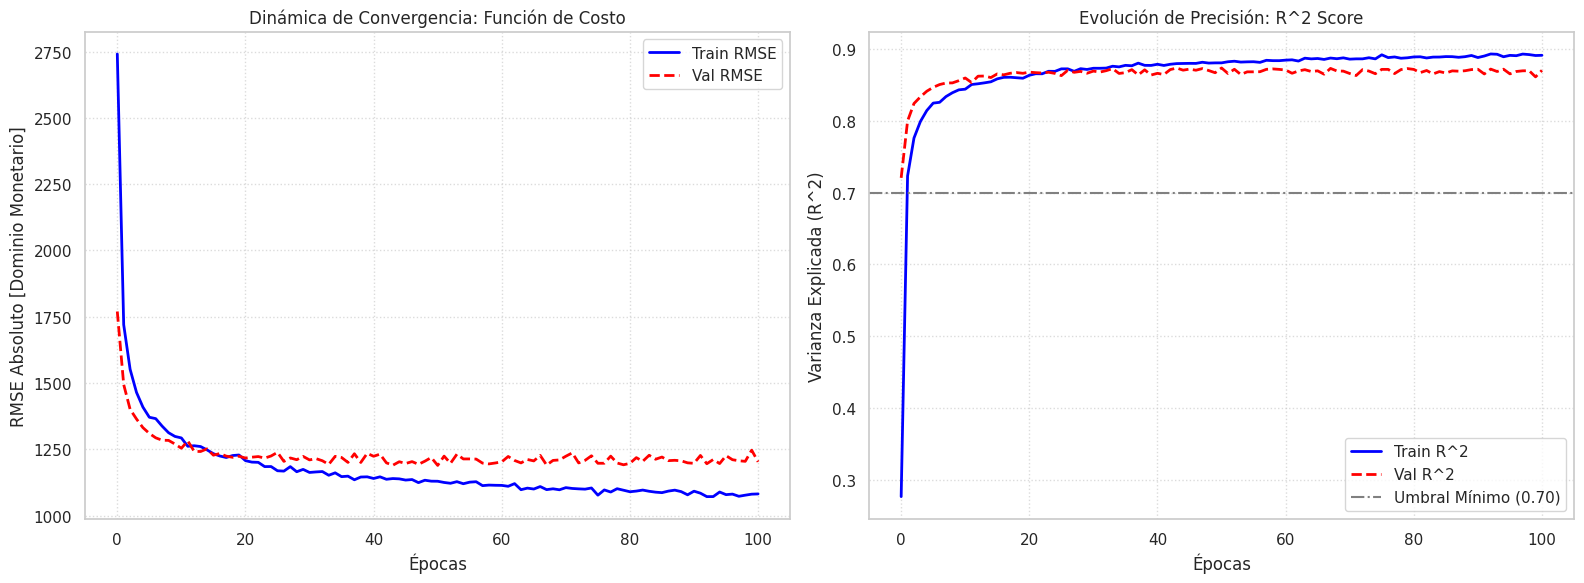

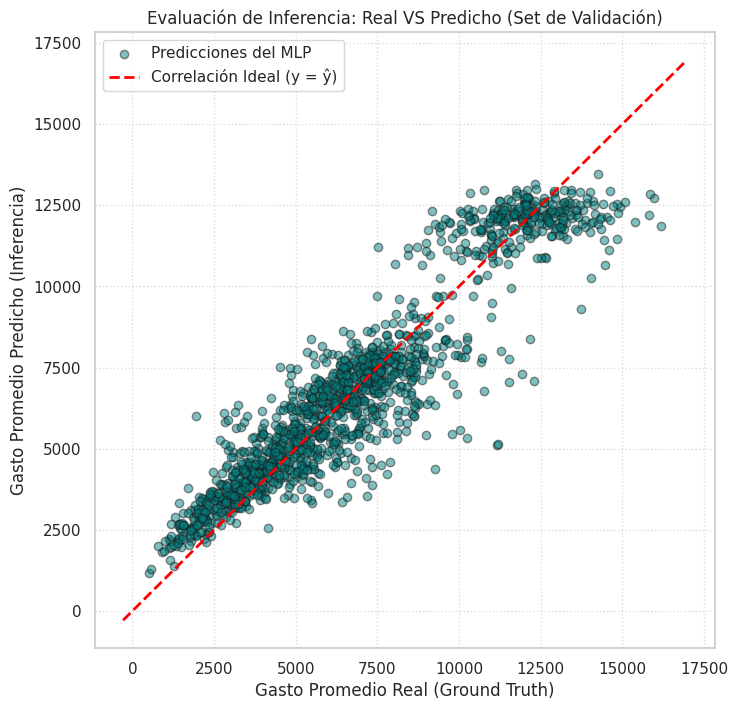

In [74]:
# Evaluacion

min_plotting_len = min(len(train_losses), len(val_losses), len(train_r2), len(val_r2))
actual_epochs_trained = min_plotting_len # Use this as the consistent length for plotting

# Recalculate unscaled losses (assuming scaler_y and train_losses/val_losses are available)
# Extracción del factor de escala (desviación estándar del vector target original)
sigma_y = scaler_y.scale_

# Proyección afín del RMSE al dominio monetario real
train_losses_unscaled = np.array(train_losses[:actual_epochs_trained]) * sigma_y
val_losses_unscaled = np.array(val_losses[:actual_epochs_trained]) * sigma_y


# 1. Dinámica de Convergencia: Costo RMSE y Varianza Explicada (R^2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Trayectoria de la Función de Costo (RMSE desescalado)
axes[0].plot(range(actual_epochs_trained), train_losses_unscaled, label='Train RMSE', color='blue', linewidth=2)
axes[0].plot(range(actual_epochs_trained), val_losses_unscaled, label='Val RMSE', color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('RMSE Absoluto [Dominio Monetario]')
axes[0].set_title('Dinámica de Convergencia: Función de Costo')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

# Trayectoria del Coeficiente de Determinación (R^2)
axes[1].plot(range(actual_epochs_trained), train_r2[:actual_epochs_trained], label='Train R^2', color='blue', linewidth=2)
axes[1].plot(range(actual_epochs_trained), val_r2[:actual_epochs_trained], label='Val R^2', color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Varianza Explicada (R^2)')
axes[1].set_title('Evolución de Precisión: R^2 Score')
axes[1].axhline(y=0.70, color='gray', linestyle='-.', label='Umbral Mínimo (0.70)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
print(f"Final R^2 score on the validation set: {val_r2[-1]:.3f}")
plt.show()


# 2. Evaluación del Grafo de Dispersión (Real VS Predicho)
model.eval()
with torch.no_grad():
    # Inferencia estática migrando la matriz de validación al acelerador
    X_val_gpu = X_test_tensor.to(device)
    y_val_pred_tensor = model(X_val_gpu)

    # Descenso de gradientes tensores a RAM y aplicación de escala inversa
    y_pred_np = scaler_y.inverse_transform(y_val_pred_tensor.cpu().numpy())
    y_real_np = scaler_y.inverse_transform(y_test_tensor.numpy())

plt.figure(figsize=(8, 8))
plt.scatter(y_real_np, y_pred_np, alpha=0.5, color='teal', edgecolor='k', label='Predicciones del MLP')

# Extracción de límites del plano para trazar el vector identidad de 45°
limits = [np.min([plt.xlim(), plt.ylim()]), np.max([plt.xlim(), plt.ylim()])]
plt.plot(limits, limits, color='red', linestyle='--', linewidth=2, label='Correlación Ideal (y = ŷ)')

plt.xlabel('Gasto Promedio Real (Ground Truth)')
plt.ylabel('Gasto Promedio Predicho (Inferencia)')
plt.title('Evaluación de Inferencia: Real VS Predicho (Set de Validación)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### 2d) Conclusiones finales (0.5 puntos)
Redactar de manera detallada las conclusiones finales y si se cumplió con el objetivo o no.

- Se probaron distintas arquitecturas, mas capas y mas neuronas no mejora la performance
- Para manejar la regularizacion se probaron distintos valores de dropout a distintas capas, lo que mejoro un poco los resultados
- Tambien se agrego la tecnica de EarlyStopping para evitar el overfitting
- Para las capas ocultas probamos distintas activaciones como Relu y sus derivadas, y la que mejor performance nos dio es LakyRelu. Al tener valores negativos por el StandardScaler, LeakyReLU mantiene un gradiente distinto de cero, evitando que las neuronas se apaguen
- Para la capa de salida, al ser una regresion, no usamos ninguna funcion de activacion
- Se utilizo RMSE como funcion de costo, para penalizar un poco mas a los errores grandes, como asi tambien para facilitar la interpretabilidad de los resultados al mantener las mismas unidades de medida
- Utiulizamos Adam Mini-Batch como algoritmo de optimizacion, ya que como vimos en el punto 1 es el que mejor funciona. Probamos con distintos lotes de batch (desde 32 hasta 2048) y generalmente tuvimos mejores resultados son valores altos (1024). Cabe destacar que para batchsizes pequenos se observa como el tiempo que demora la red en entrenarse es considerablemente mayor, lo cual tiene sentido teniendo en cuenta que se hacen muchas mas actualizaciones de los parametros por epoch
- Con respecto al Learning Rate probamos con valores entre 0.01 y 0.001, y la curva de convergencia no tuvo oscilaciones ni picos. Nos quedamos con 0.001
- Con respecto al numero de epocas, como implementamos early stopping, dejamos un numero alto de epocas (1000) con una paciecnia de 100
- Aun cuando probamos incrementando la complejidad de la red, so se cumplio con el objetivo de obtener un R2 en Test de 0.7, en nuestro experimento llegamos apenas al 0.625. Esto indica que el cuello de botella seguramente este en la calidad de los datos de entrada.
- Creando atributos agregados por usuario (min, max, std) el R2 mejora notablemente, pero tengo dudas si estamos incurriendo en Data Leakage

